# Devoir 3 - Validation

##### A) Sachant que la LBM converge supposément à l’ordre 2 en espace (mais aussi en temps, mais ce n’est pas pertinent vu que l’on se préoccupe uniquement de l’état stationnaire), évaluer l’incertitude numérique $u_{\text{num}}$ au moyen d’une méthode appropriée vue en vérification de solution.
##### Ici aussi, rapporter clairement ce que vous avez fait pour estimer cette incertitude (c.-à-d. donner la liste des paramètres, l’étendue de l’analyse effectuée et tous les graphiques pertinents).
##### Pour faire une analyse de convergence appropriée, il vous faudra fixer la géométrie du milieu fibreux en gardant seulement, pour cette étape, le « seed » du générateur aléatoire constant (choisir n’importe quel entier) et garder $N_x \times \Delta x$ constant, de sorte que la position des fibres et la dimension du domaine restent elles aussi constantes.

  Branche >10% : GCI (Fs=3, p_exp=2.00)
  k_num = 29.0979 µm²
  u_num = 0.0880 µm²


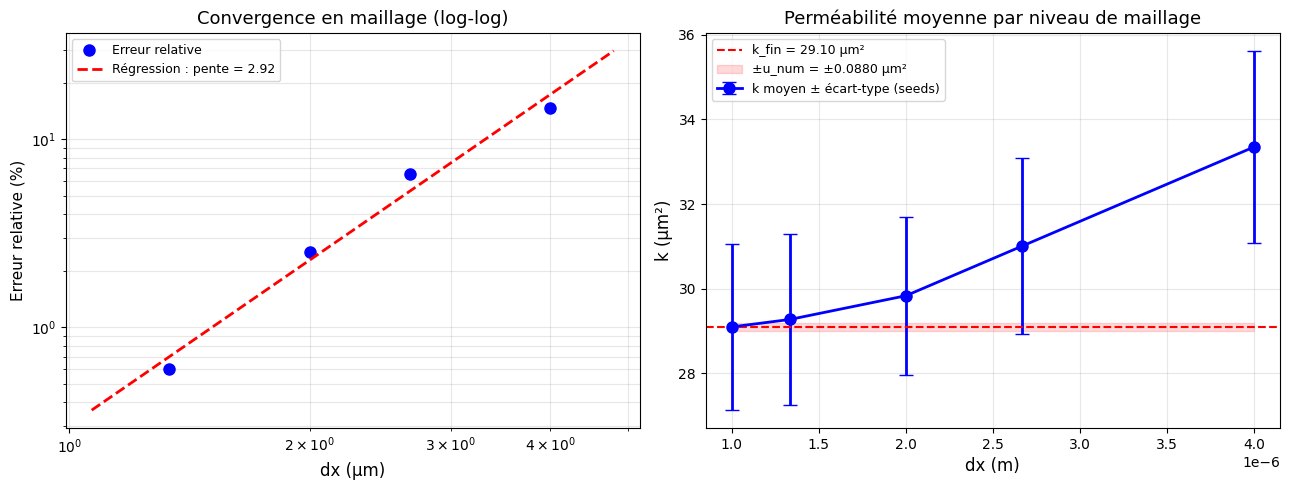

Graphique sauvegardé : convergence_maillage.png


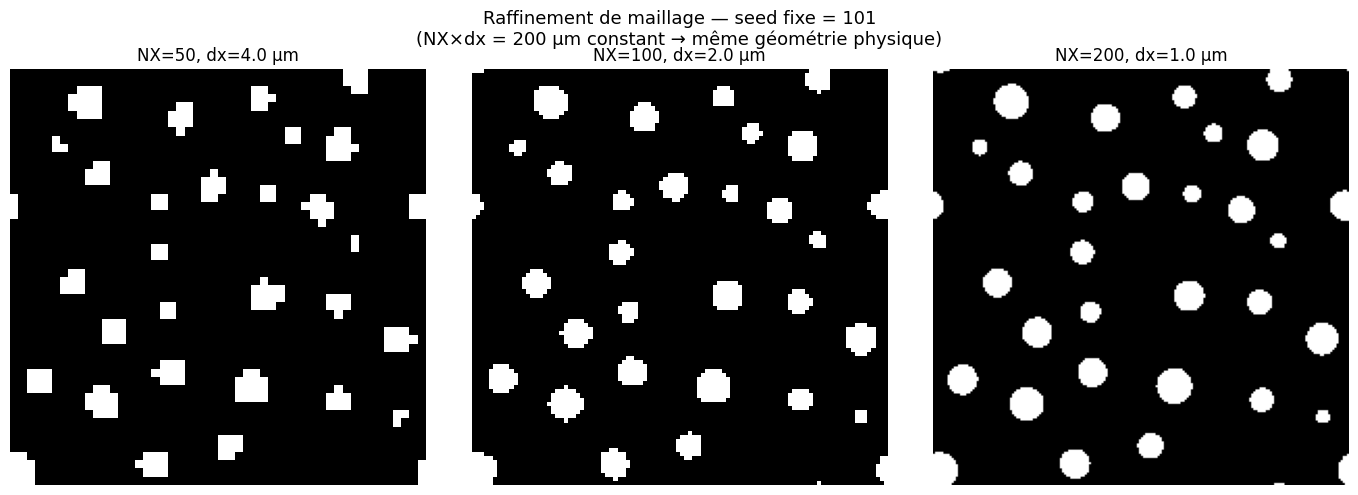

Graphique sauvegardé : raffinement_geometrie.png
  NX= 50 : k_moy = 33.3472 ± 2.2730 µm²
  NX= 75 : k_moy = 31.0051 ± 2.0840 µm²
  NX=100 : k_moy = 29.8344 ± 1.8656 µm²
  NX=150 : k_moy = 29.2739 ± 2.0092 µm²
  NX=200 : k_moy = 29.0979 ± 1.9664 µm²
  Ordre apparent p    = 2.9242
  |p - pf|/pf         = 46.21 %
  k_num               = 29.0979 µm²
  u_num             = 0.0880 µm²


In [1]:
"""
Question A — Détermination de l'erreur numérique de la perméabilité calculée par LBM en fonction du maillage
"""
 
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.stats import linregress

sys.path.append('..')
from devoir3_lbm_accelerated import Generate_sample, LBM


# ==============================================================================
# PARAMÈTRES FIXES
# ==============================================================================

DELTA_P       = 0.1
PORO         = 0.9
MEAN_FIBER_D = 12.5
ECART_TYPE_D = 2.85
 
# Maillages — NX*dx = constante
NX_LIST = [50, 75, 100, 150, 200]
DX_LIST = [4e-6, 200/75*1e-6, 2e-6, 200/150*1e-6, 1e-6]
 
# Seeds de génération aléatoire pour la moyenne sur plusieurs géométries
SEEDS = [101, 102, 103, 104, 105, 106, 107]

# Ordre de convergence théorique de la LBM
PF = 2
 
# Facteur de raffinement entre les deux maillages les plus fins
R = 2


# ==============================================================================
# SIMULATIONS - MOYENNE SUR PLUSIEURS SEEDS PAR MAILLAGE
# ==============================================================================

# Moyenne sur plusieurs seeds pour chaque maillage
k_means = []   # perméabilité moyenne par maillage
k_stds  = []   # écart-type par maillage

for i in range(len(NX_LIST)):
    nx = NX_LIST[i] 
    dx = DX_LIST[i]
    k_list_seed = []

    for seed in SEEDS:
        filename = f'fiber_mat_NX{nx}_seed{seed}.tiff'
        d_eq = Generate_sample(seed, filename, MEAN_FIBER_D, ECART_TYPE_D, PORO, nx, dx, plot=False)
        k = LBM(filename, nx, DELTA_P, dx, d_eq, plot=False)
        k_list_seed.append(k)
 
    k_mean = np.mean(k_list_seed) # perméabilité moyenne sur les seeds
    k_std  = np.std(k_list_seed, ddof=1) # écart-type sur les seeds (n-1 pour échantillon)
    k_means.append(k_mean) # moyenne pour le maillage i
    k_stds.append(k_std) # écart-type pour le maillage i
 
k_means  = np.array(k_means) # transformation en array pour les calculs
k_stds   = np.array(k_stds)
dx_array = np.array(DX_LIST)
 

# ==============================================================================
# ERREUR RELATIVE PAR RAPPORT AU MAILLAGE LE PLUS FIN
# ==============================================================================

k_fin   = k_means[-1] 
err_rel    = np.abs(k_fin - k_means[:-1]) / k_fin
dx_coarse  = dx_array[:-1] # dx des maillages plus grossiers (NX=50, 75, 100, 150)
 

# ==============================================================================
# RÉGRESSION LOG-LOG — ORDRE APPARENT P
# ==============================================================================

log_dx  = np.log(dx_coarse)
log_err = np.log(err_rel)
 
slope, intercept, r_value, _, _ = linregress(log_dx, log_err)
p_apparent = slope

# Calcul du rapport entre l'ordre de convergence apparent p et l'ordre théorique
rapport = abs((p_apparent - PF) / PF)


# ==============================================================================
# CALCUL DE u_num ET k_num
# ==============================================================================

# Distinction des trois cas selon la valeur du rapport (cf. diapo 24 du cours sur la Vérification de solution)
if rapport < 0.01:
    k_num = k_means[-1] + (k_means[-1] - k_means[-2]) / (r**pf - 1)
    u_num    = 0.0
    print(f"  Branche <1% : extrapolation de Richardson")
    print(f"  k_num = k_extrap = {k_num:.4f} µm²  (pas d'incertitude)")
elif rapport <= 0.10:
    GCI = (1.25 / (R**PF - 1)) * abs(k_means[-2] - k_means[-1])
    u_num = GCI /2
    k_num = k_means[-1]
    print(f"  Branche ≤10% : GCI (Fs=1.25, p=pf={PF})")
    print(f"  k_num = {k_num:.4f} µm²")
    print(f"  u_num = {u_num:.4f} µm²")
else:
    p_exp = min(max(0.5, p_apparent), PF)
    GCI = (3 / (R**p_exp - 1)) * abs(k_means[-2] - k_means[-1])
    u_num = GCI / 2
    k_num = k_means[-1]
    print(f"  Branche >10% : GCI (Fs=3, p_exp={p_exp:.2f})")
    print(f"  k_num = {k_num:.4f} µm²")
    print(f"  u_num = {u_num:.4f} µm²")


# ==============================================================================
# GRAPHIQUE 1 — Erreur relative en log-log + régression
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
ax1 = axes[0]
dx_fit = np.linspace(dx_coarse.min() * 0.8, dx_coarse.max() * 1.2, 100)
err_fit = np.exp(intercept) * dx_fit**p_apparent
 
ax1.loglog(dx_coarse * 1e6, err_rel * 100, 'bo', markersize=8, linewidth=2, label='Erreur relative')
ax1.loglog(dx_fit * 1e6, err_fit * 100, 'r--', linewidth=2, label=f'Régression : pente = {p_apparent:.2f}')
ax1.set_xlabel('dx (µm)', fontsize=12)
ax1.set_ylabel('Erreur relative (%)', fontsize=11)
ax1.set_title('Convergence en maillage (log-log)', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, which='both', alpha=0.3)
 
 
# ==============================================================================
# GRAPHIQUE 2 — k moyen ± écart-type en fonction de dx
# ==============================================================================
 
ax2 = axes[1]
ax2.errorbar(dx_array, k_means, yerr=k_stds, fmt='bo-', markersize=8, linewidth=2, capsize=5, label='k moyen ± écart-type (seeds)')
ax2.axhline(k_fin, color='r', linestyle='--', linewidth=1.5, label=f'k_fin = {k_fin:.2f} µm²')
ax2.fill_between(dx_array, k_fin - u_num, k_fin + u_num, color='red', alpha=0.15,label=f'±u_num = ±{u_num:.4f} µm²')
ax2.set_xlabel('dx (m)', fontsize=12)
ax2.set_ylabel('k (µm²)', fontsize=12)
ax2.set_title('Perméabilité moyenne par niveau de maillage', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('convergence_maillage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : convergence_maillage.png")
 
 
# ==============================================================================
# GRAPHIQUE 3 — Raffinement de maillage (seed fixe → même géométrie physique)
# ==============================================================================
 
SEED_VISU = 101
NX_VISU   = [50, 100, 200]
DX_VISU   = [4e-6, 2e-6, 1e-6]
 
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 5))
fig2.suptitle(f'Raffinement de maillage — seed fixe = {SEED_VISU}\n' f'(NX×dx = 200 µm constant → même géométrie physique)',fontsize=13)
 
for j, (nx, dx) in enumerate(zip(NX_VISU, DX_VISU)):
    filename = f'fiber_mat_visu_NX{nx}.tiff'
    Generate_sample(SEED_VISU, filename, MEAN_FIBER_D, ECART_TYPE_D, PORO, nx, dx, plot=False)
    img = np.array(Image.open(filename))
    axes2[j].imshow(img, cmap='gray', origin='lower')
    axes2[j].set_title(f'NX={nx}, dx={dx * 1e6:.1f} µm', fontsize=12)
    axes2[j].axis('off')
 
plt.tight_layout()
plt.savefig('raffinement_geometrie.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : raffinement_geometrie.png")


# ==============================================================================
# RÉSUMÉ FINAL
# ==============================================================================

for i, NX in enumerate(NX_LIST):
    print(f"  NX={NX:3d} : k_moy = {k_means[i]:.4f} ± {k_stds[i]:.4f} µm²")
print(f"  Ordre apparent p    = {p_apparent:.4f}")
print(f"  |p - pf|/pf         = {rapport*100:.2f} %")
print(f"  k_num               = {k_num:.4f} µm²")
print(f"  u_num             = {u_num:.4f} µm²")

##### B)  Évaluer l’incertitude $u_{\text{input}}$ résultant de la propagation de l’incertitude des données d’entrée à l’aide d’un maillage suffisamment fin.

##### Pour ce faire, il vous faudra, par exemple, calculer la perméabilité pour diverses structures générées dont la porosité suit une distribution gaussienne (approche Monte Carlo classique).

##### Rapporter clairement ce que vous avez fait pour estimer cette incertitude (c.-à-d. donner la liste des paramètres, l’étendue de l’analyse effectuée et tous les graphiques que vous jugerez pertinents, en particulier la PDF ou la CDF des perméabilités générées par le code).

##### La distribution obtenue ne sera pas une distribution gaussienne (c’est-à-dire normale), mais log-normale (c’est-à-dire que ce sont les logarithmes des valeurs qui seront distribués de façon normale).

Médiane des perméabilités simulées : 29.37 µm²
Facteur de Variation Géométrique : 1.15
Incertitude asymétrique : u_input⁻ = 3.90 µm², u_input⁺ = 4.49 µm²


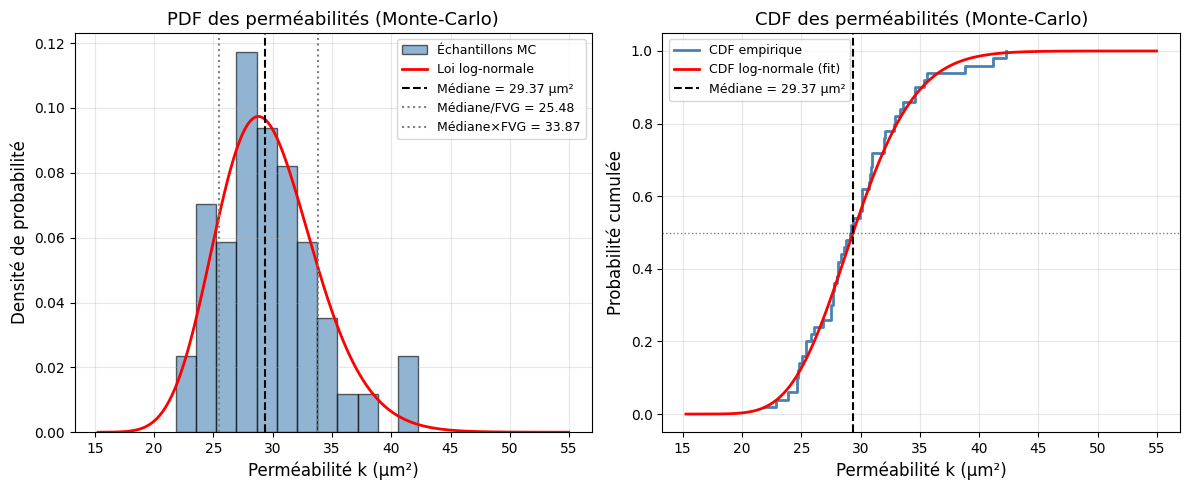

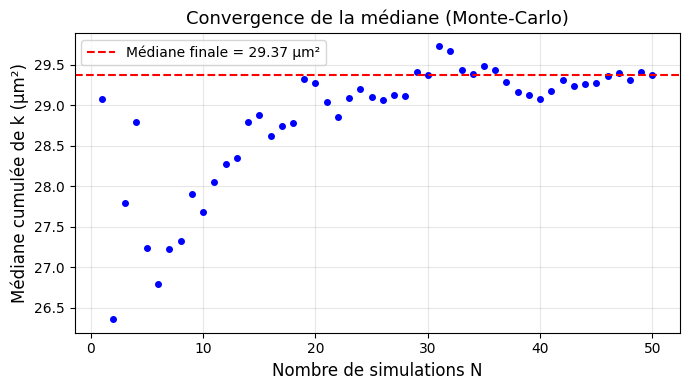

In [2]:
"""
Question B — Incertitude u_input par Monte-Carlo
Propagation de l'incertitude sur la porosité et le diamètre des fibres.
"""

import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

sys.path.append('..')

from devoir3_lbm_accelerated import Generate_sample, LBM


# ==============================================================================
# PARAMÈTRES
# ==============================================================================

N_MONTE_CARLO    = 50

# Paramètres physiques (Tableau 1)
ECART_TYPE_PORO = 7.50e-3
PORO         = 0.9
MEAN_FIBER_D = 12.5
ECART_TYPE_D = 2.85

# Paramètres LBM
NX           = 100         # Taille du domaine — Ne pas prendre le maillage le plus fin (NX=200) pour limiter le temps de calcul (l'erreur numérique est négligeable pour NX=100)
DX           = 2e-6        # Taille d'une cellule
DELTA_P      = 0.1         # Chute de pression

FILENAME     = 'fiber_mat_MC.tiff'


# ==============================================================================
# BOUCLE MONTE-CARLO
# ==============================================================================

rng = np.random.default_rng(seed=42)  # Même seed pour reproductibilité des tirages de porosité

permeabilities = []
porosities_input = []

# Boucle Monte-Carlo pour 50 échantillons
for i in range(N_MONTE_CARLO):
    poro_sample = rng.normal(PORO, ECART_TYPE_PORO) # Tirage de la porosité selon une loi normale 
    porosities_input.append(poro_sample)

   # Génération de l'échantillon 
    d_eq = Generate_sample(
        seed     = 0,          # La distribution de diamètres varie à chaque appel
        filename = FILENAME,
        mean_d   = MEAN_FIBER_D,
        std_d    = ECART_TYPE_D,
        poro     = poro_sample,
        nx       = NX,
        dx       = DX,
        plot     = False
    )

    # Simulation LBM pour calcul de la perméabilité
    k = LBM(
        filename     = FILENAME,
        NX           = NX,
        deltaP       = DELTA_P,
        dx           = DX,
        d_equivalent = d_eq,
        plot         = False
    )

    permeabilities.append(k)

permeabilities = np.array(permeabilities) # Transformation en array pour les calculs statistiques


# ==============================================================================
# ANALYSE DE LA DISTRIBUTION LOG-NORMALE
# ==============================================================================

log_k    = np.log(permeabilities)
mu_log   = np.mean(log_k)
sigma_log = np.std(log_k, ddof=1)

# Paramètres log-normaux
mediane = np.exp(mu_log)         # Médiane de la distribution log-normale
FVG     = np.exp(sigma_log)      # Facteur de Variation Géométrique

print(f"Médiane des perméabilités simulées : {mediane:.2f} µm²")
print(f"Facteur de Variation Géométrique : {FVG:.2f}")

# Incertitude asymétrique
u_minus = mediane - mediane / FVG
u_plus  = mediane * FVG - mediane 

print(f"Incertitude asymétrique : u_input⁻ = {u_minus:.2f} µm², u_input⁺ = {u_plus:.2f} µm²")

# Vérification fit log-normal avec scipy
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(permeabilities, floc=0)

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# ==============================================================================
# GRAPHIQUE 1 — PDF et CDF
# ==============================================================================

# PDF
ax1 = axes[0]
x_range = np.linspace(permeabilities.min() * 0.7, permeabilities.max() * 1.3, 300)
pdf_fitted = stats.lognorm.pdf(x_range, s=shape_ln, scale=scale_ln)

ax1.hist(permeabilities, bins=12, density=True, alpha=0.6, color='steelblue',
         edgecolor='black', label='Échantillons MC')
ax1.plot(x_range, pdf_fitted, 'r-', linewidth=2, label='Loi log-normale')
ax1.axvline(mediane, color='k', linestyle='--', linewidth=1.5, label=f'Médiane = {mediane:.2f} µm²')
ax1.axvline(mediane / FVG, color='gray', linestyle=':', linewidth=1.5, label=f'Médiane/FVG = {mediane/FVG:.2f}')
ax1.axvline(mediane * FVG, color='gray', linestyle=':', linewidth=1.5, label=f'Médiane×FVG = {mediane*FVG:.2f}')
ax1.set_xlabel('Perméabilité k (µm²)', fontsize=12)
ax1.set_ylabel('Densité de probabilité', fontsize=12)
ax1.set_title('PDF des perméabilités (Monte-Carlo)', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# CDF
ax2 = axes[1]
k_sorted = np.sort(permeabilities)
cdf_emp  = np.arange(1, N_MONTE_CARLO + 1) / N_MONTE_CARLO
cdf_fit  = stats.lognorm.cdf(x_range, s=shape_ln, scale=scale_ln)

ax2.step(k_sorted, cdf_emp, where='post', color='steelblue', linewidth=2, label='CDF empirique')
ax2.plot(x_range, cdf_fit, 'r-', linewidth=2, label='CDF log-normale (fit)')
ax2.axvline(mediane, color='k', linestyle='--', linewidth=1.5, label=f'Médiane = {mediane:.2f} µm²')
ax2.axhline(0.5, color='k', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_xlabel('Perméabilité k (µm²)', fontsize=12)
ax2.set_ylabel('Probabilité cumulée', fontsize=12)
ax2.set_title('CDF des perméabilités (Monte-Carlo)', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('MC_PDF_CDF.png', dpi=150, bbox_inches='tight')
plt.show()


# ==============================================================================
# GRAPHIQUE 2 — Convergence de la médiane en fonction de N
# ==============================================================================

fig2, ax3 = plt.subplots(figsize=(7, 4))
medianes_cumulees = [np.exp(np.mean(np.log(permeabilities[:n+1]))) for n in range(N_MONTE_CARLO)]
ax3.plot(range(1, N_MONTE_CARLO + 1), medianes_cumulees, 'bo', markersize=4)
ax3.axhline(mediane, color='r', linestyle='--', linewidth=1.5, label=f'Médiane finale = {mediane:.2f} µm²')
ax3.set_xlabel('Nombre de simulations N', fontsize=12)
ax3.set_ylabel('Médiane cumulée de k (µm²)', fontsize=12)
ax3.set_title('Convergence de la médiane (Monte-Carlo)', fontsize=13)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('MC_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

##### C) Évaluer l’incertitude $u_D$ des données expérimentales en tenant compte de l’incertitude du perméamètre.

In [3]:
"""
Question C - Incertitude u_D des données expérimentales
"""

# Valeurs tirées du Tableau 1

u_repro    = 14.7    # Écart-type de la distribution supposée gaussienne des mesures de perméabilité lors d’un test de reproductibilité
u_permea   = 10.0    # Incertitude sur les mesures du perméamétre donnée par le manufacturier 

# Calcul de l'incertitude totale en combinant les contributions
u_D = (u_repro**2 + u_permea**2)**0.5

print(f"L'incertitude des données expérimentales (u_D) est estimée à : {u_D:.2f} µm².")

L'incertitude des données expérimentales (u_D) est estimée à : 17.78 µm².


Le résultat $u_D = 17,78 \ µm^2$ représente environ 22% de la médiane mesurée (80,6 µm²), ce qui est assez élevé.

**Réponse :** 


##### D) Obtenir l’erreur de la simulation $E$ en prenant la solution numérique $S$ et la valeur expérimentale $D$ comme étant les médianes des valeurs de perméabilité obtenues numériquement et expérimentalement.

In [4]:
"""
Question D — Erreur de simulation E = S - D
"""

import numpy as np
 
S_median = 29.37   # médiane des perméabilités simulées (question B)
D_median = 80.6     # médiane des perméabilités mesurées (Tableau 1)

# Calcul de l'erreur de simulation E 
E = S_median - D_median

print(f"L'erreur de simulation E = S_median - D_median est estimée à : {E:.2f} µm²")

L'erreur de simulation E = S_median - D_median est estimée à : -51.23 µm²


##### E) Déterminer l’erreur du modèle $\delta_{\text{model}}$ suivant le standard ASME V\&V20 et conclure sur l’adéquation du modèle numérique ainsi que sur les pistes d’amélioration éventuelles, si nécessaire.

In [6]:
"""
Question E — Erreur du modèle
"""

import numpy as np

# ==============================================================================
# DONNÉES — RÉSULTATS DES QUESTIONS PRÉCÉDENTES
# ==============================================================================

u_num         = 0.0880   # incertitude numérique estimée à partir de l'étude de convergence (question A)
u_input_minus = 3.90     # u_input vers le bas (question B)
u_input_plus  = 4.49     # u_input vers le haut (question B)
S_median      = 29.37    # médiane des perméabilités simulées (question B)
u_repro       = 14.7     # (Tableau 1)
u_permea      = 10.0     # (Tableau 1)
D_median      = 80.6     # (Tableau 1)

u_D           = np.sqrt(u_repro**2 + u_permea**2) # incertitude des données expérimentales (question C)
E             = S_median - D_median # erreur de simulation (question D)

k             = 2 # Facteur de couverture k=2 pour intervalle de confiance à 95.4%



# ==============================================================================
# CALCULS
# ==============================================================================

# u_val asymétrique : deux valeurs (bas et haut)
u_minus = np.sqrt(u_num**2 + u_input_minus**2 + u_D**2)
u_plus  = np.sqrt(u_num**2 + u_input_plus**2  + u_D**2)
 
# Intervalle de confiance à 95.4% sur δ_model
borne_inf = E - k * u_plus    # borne inférieure
borne_sup = E + k * u_minus    # borne supérieure

print(f"Erreur de simulation E = {E:.2f} µm²")
print(f"  u_val⁻ = {u_minus:.4f} µm², u_val⁺ = {u_plus:.4f} µm²")
print(f"  E - k·u_val⁺ ≤ δ_model ≤ E + k·u_val⁺")
print(f"  δ_model appartient à l'intervalle  [{borne_inf:.4f} , {borne_sup:.4f}] µm²")



Erreur de simulation E = -51.23 µm²
  u_val⁻ = 18.2019 µm², u_val⁺ = 18.3373 µm²
  E - k·u_val⁺ ≤ δ_model ≤ E + k·u_val⁺
  δ_model appartient à l'intervalle  [-87.9047 , -14.8263] µm²


L'erreur du modèle appartient à un intervalle négatif donc le modèle numérique n'est pas adéquat. 